In [ ]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from volatility_forecasting.data.loader import download_price_data
from volatility_forecasting.features.preprocessing import compute_log_returns

In [19]:
# Set seaborn color palette to pastel
sns.set_palette("pastel")

# Set matplotlib style to pastel 
#plt.style.use("seaborn-pastel")

# Apply grid in grey to all plots
plt.rcParams["grid.color"] = "grey"
plt.rcParams["grid.linestyle"] = "--"

## Visualizations

In [3]:
# Download price data for S&P 500 and VIX and log transform prices

# SP500
sp500 = download_price_data("^GSPC")
sp500 = compute_log_returns(sp500)

# VIX
vix = download_price_data("^VIX")
vix = compute_log_returns(vix)

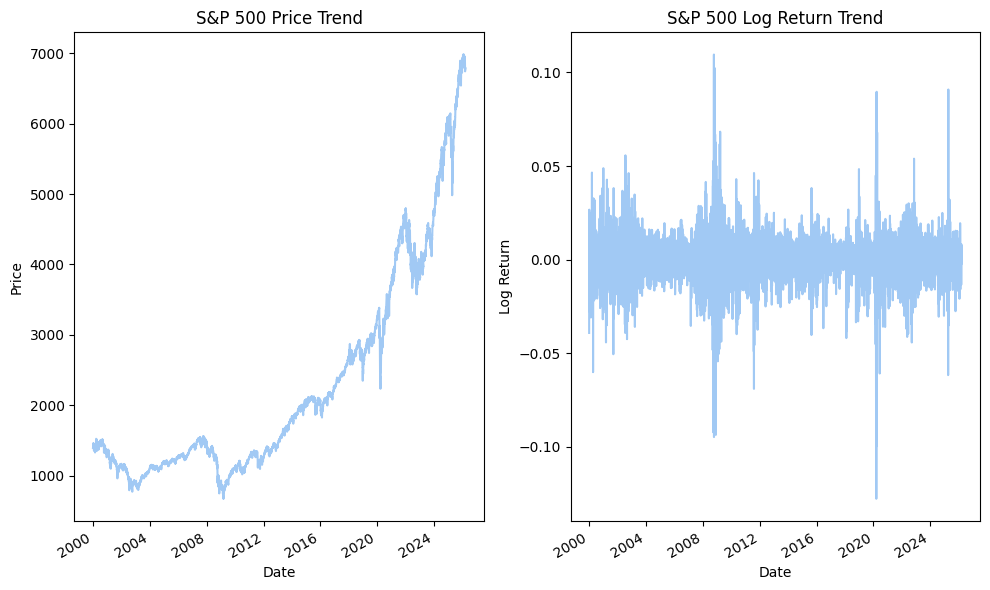

In [20]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 6))

# plot the price and log return trends for S&P 500
sp500["price"].plot(ax=ax[0], title="S&P 500 Price Trend", ylabel="Price")
sp500["log_return"].plot(ax=ax[1], title="S&P 500 Log Return Trend", ylabel="Log Return")

plt.tight_layout()

#### Volatility is the lowest right before it spikes
- S&P 500 prices exhibit a long-term upward trend and chaning varianes, indicating non-stationarity in boht mean and variance
- Rolling volatility shows clear clustering, where periods of high volatility are followed bu high volatility and calm periods by calm conditions. This indicates persistence in volatility over time.
- Volatility is mean-reverting, where extreme spikes (eg high VIX levels) are typically followed by a gradual decline toward normal levels.

- Volatility spikes align with VIX spikes
- Volatility stays high after crises -> volatility clustering
    - Markets dont calm down immediately after panic -> fear decays slowly
- Calm periods are long; crises short
    - Markets are calm most of the time but extreme events dominate risk
- Volatility spikes harder, increases less (negative peaks have greater magnitude than positive ones)

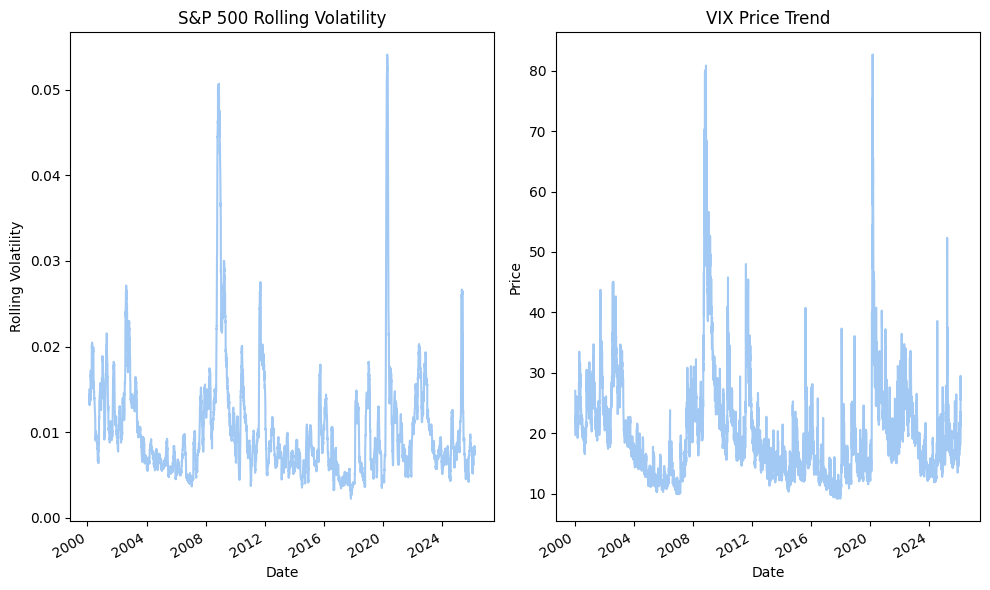

In [18]:
# plot 30-day rolling volatility for both S&P 500 and VIX to identify periods of high volatility
# and potential regime shifts
# expectations - clustering, crisis spikes, regime shifts

rolling_window = 30
sp500["rolling_volatility"] = sp500["log_return"].rolling(window=rolling_window).std()
vix["rolling_volatility"] = vix["log_return"].rolling(window=rolling_window).std()

fig, ax = plt.subplots(ncols=2, figsize=(10, 6))
sp500["rolling_volatility"].plot(ax=ax[0], title="S&P 500 Rolling Volatility", ylabel="Rolling Volatility")
vix["price"].plot(ax=ax[1], title="VIX Price Trend", ylabel="Price")
#vix["rolling_volatility"].plot(ax=ax[1], title="VIX Rolling Volatility", ylabel="Rolling Volatility")
plt.tight_layout()
plt.show()

In [ ]:
# missing price values? clean datetime index?
# fix plot visualization - use seaborn style, pastel colors, grid in grey


## Stationarity Test

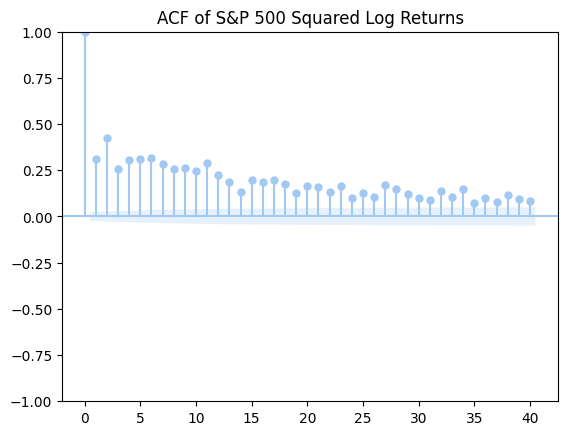

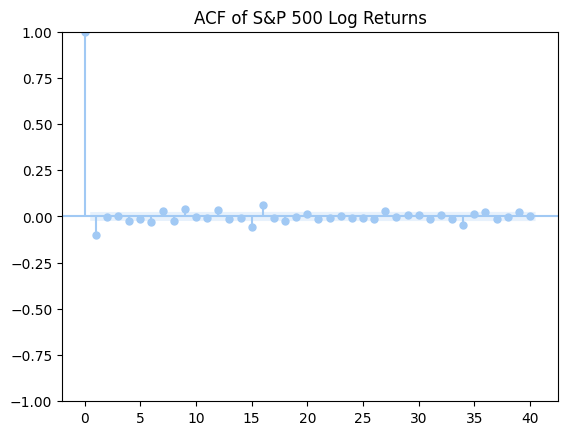

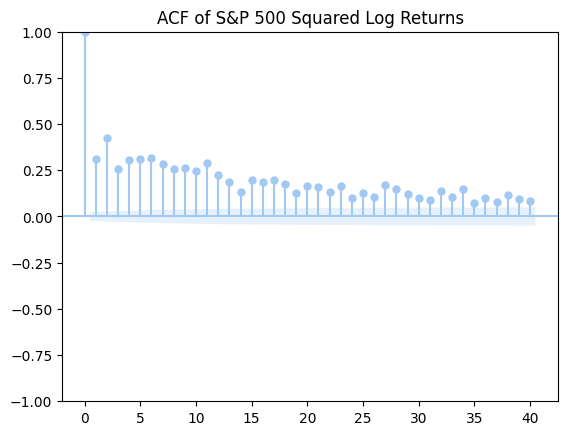

In [ ]:
# plot afc on log returns and log returns squared to check for stationarity and seasonality
plot_acf(sp500["log_return"], lags=40, title="ACF of S&P 500 Log Returns")
plot_acf(sp500["log_return"] ** 2, lags=40, title="ACF of S&P 500 Squared Log Returns")

- Significant spikes at multiple lags for squared returns

In [ ]:
# ADF test for stationarity on log returns and price levels

adf_log_return = adfuller(sp500["log_return"].dropna())
adf_price = adfuller(sp500["price"].dropna())

## Staionarity and Autocorrelation

# ADF test on prices
# ADF test on returns
# ACF of returns
# ACF of squared returns

## Critical Thinking

Why do returns show low autocorrelation?

Why do squared returns show persistance?

What does that imply about modeling?

In [ ]:
# README - problem stattement, why volatility forecasting matters, data sources, key findings, next steps